In [1]:
# %% 1) Imports & small utils
import os
import math
import glob
import zipfile
from pathlib import Path

import numpy as np
import cv2
import matplotlib.pyplot as plt
from IPython.display import HTML, display

plt.rcParams["figure.facecolor"] = "white"
plt.rcParams["axes.facecolor"] = "white"

def ensure_dir(path) -> Path:
    p = Path(path)
    p.mkdir(parents=True, exist_ok=True)
    return p

def open_video(video_path: str):
    cap = cv2.VideoCapture(video_path)
    if not cap.isOpened():
        raise RuntimeError(f"Could not open video: {video_path}")
    return cap

def get_metadata(video_path: str) -> dict:
    cap = open_video(video_path)
    fps = cap.get(cv2.CAP_PROP_FPS) or 0.0
    frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT) or 0)
    width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH) or 0)
    height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT) or 0)
    duration = frames / fps if fps > 0 else (
        cap.get(cv2.CAP_PROP_DURATION) / 1000.0 if cap.get(cv2.CAP_PROP_DURATION) > 0 else None
    )
    cap.release()
    return {
        "video_path": video_path,
        "fps": fps,
        "frames": frames,
        "duration_sec": duration,
        "width": width,
        "height": height,
    }


In [2]:
# %% 2) Download dataset & choose video (Kaggle) — writes chosen path to 'download_info.txt'
# If kagglehub isn't available, comment this cell and set `video_path` manually in cell 3.

DATASET = "mistag/short-videos"
PREFERRED_REL = "animals/elefant_1280p.mp4"
INFO_FILE = "download_info.txt"

try:
    import kagglehub

    ds_path = kagglehub.dataset_download(DATASET)
    print("Dataset path:", ds_path)

    preferred = os.path.join(ds_path, PREFERRED_REL)
    if os.path.exists(preferred):
        chosen = preferred
    else:
        mp4s = sorted(glob.glob(os.path.join(ds_path, "**", "*.mp4"), recursive=True))
        if not mp4s:
            raise RuntimeError("No .mp4 files found in the dataset.")
        chosen = mp4s[0]

    print("Chosen video:", chosen)
    Path(INFO_FILE).write_text(chosen, encoding="utf-8")
    print(f"Saved chosen path to {INFO_FILE}")

except Exception as e:
    raise RuntimeError(
        "kagglehub is not available here.\n"
        "Install it (pip install kagglehub) OR skip this cell and set `video_path` manually in the next cell."
    )


Using Colab cache for faster access to the 'short-videos' dataset.
Dataset path: /kaggle/input/short-videos
Chosen video: /kaggle/input/short-videos/animals/elefant_1280p.mp4
Saved chosen path to download_info.txt


In [3]:
# %% 3) Resolve video path & print metadata
# If you skipped cell 2, set video_path manually like:
# video_path = "/absolute/path/to/elefant_1280p.mp4"

info_file = Path("download_info.txt")
if info_file.exists():
    video_path = info_file.read_text(encoding="utf-8").strip()
else:
    # Fallback for manual path (edit this if needed)
    video_path = ""  # e.g. "/path/to/elefant_1280p.mp4"
    if not video_path:
        raise RuntimeError("No video path. Either run cell 2 or set `video_path` here.")

meta = get_metadata(video_path)
print("Video:", meta["video_path"])
print(f"FPS: {meta['fps']:.3f}")
print(f"Frames: {meta['frames']}")
print(f"Duration (s): {meta['duration_sec']:.3f}" if meta["duration_sec"] is not None else "Duration (s): unknown")
print(f"Resolution: {meta['width']}x{meta['height']}")


Video: /kaggle/input/short-videos/animals/elefant_1280p.mp4
FPS: 29.970
Frames: 1064
Duration (s): 35.502
Resolution: 1280x720


In [4]:
# %% 4) Display the video inline (HTML5 <video>)
html = f"""
<video width="720" controls>
  <source src="{video_path}" type="video/mp4">
  Your browser does not support the video tag.
</video>
"""
display(HTML(html))


Saved 107 frames to: /content/frames/elefant_1280p (~3.0 fps)


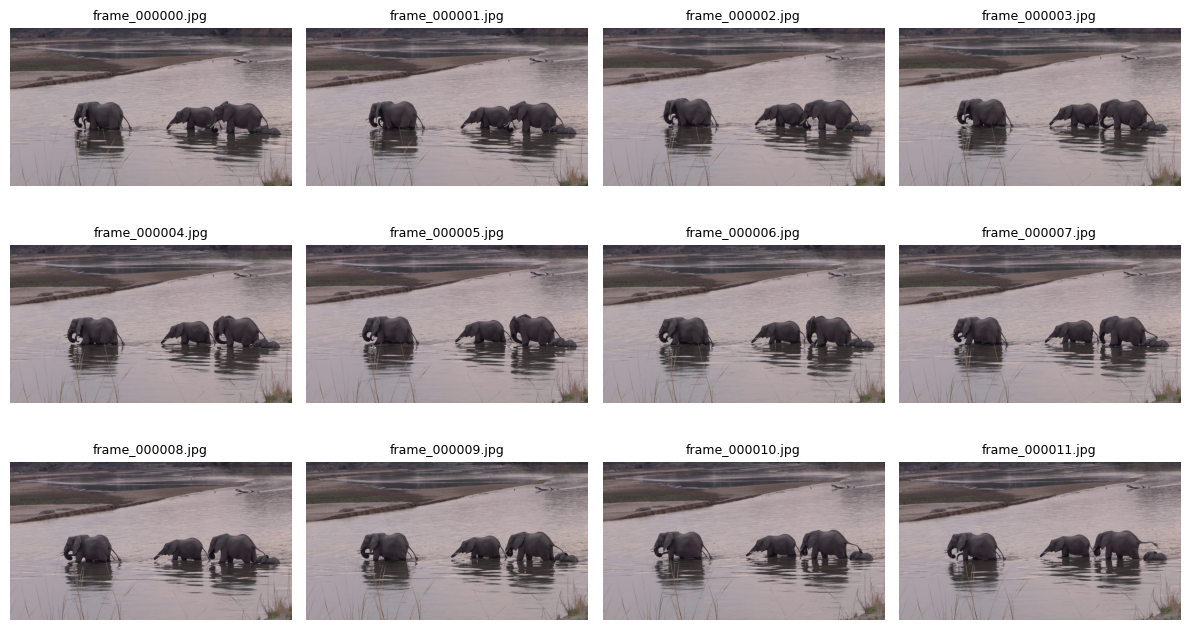

In [5]:
# %% 5) Extract frames at 3 fps (time-based) and show a preview grid
TARGET_FPS = 3.0            # extraction rate (frames per second)
BASE_OUTDIR = "frames"      # base folder for outputs

stem = Path(video_path).stem
out_dir = ensure_dir(Path(BASE_OUTDIR) / stem)

cap = cv2.VideoCapture(video_path)
if not cap.isOpened():
    raise RuntimeError(f"Could not open video: {video_path}")

target_dt = 1.0 / TARGET_FPS
next_ts = 0.0  # seconds
eps = 1e-3

saved_paths = []

while True:
    ok, frame = cap.read()
    if not ok:
        break
    t = cap.get(cv2.CAP_PROP_POS_MSEC) / 1000.0  # current timestamp in seconds
    if t + eps >= next_ts:
        p = out_dir / f"frame_{len(saved_paths):06d}.jpg"
        cv2.imwrite(str(p), frame, [int(cv2.IMWRITE_JPEG_QUALITY), 95])
        saved_paths.append(str(p))
        next_ts += target_dt

cap.release()
print(f"Saved {len(saved_paths)} frames to: {out_dir.resolve()} (~{TARGET_FPS} fps)")

# preview (up to 12 images)
preview = min(12, len(saved_paths))
if preview > 0:
    cols = 4
    rows = math.ceil(preview / cols)
    plt.figure(figsize=(cols * 3, rows * 2.3))
    for i in range(preview):
        img = cv2.imread(saved_paths[i])
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        ax = plt.subplot(rows, cols, i + 1)
        ax.imshow(img)
        ax.set_axis_off()
        ax.set_title(Path(saved_paths[i]).name, fontsize=9)
    plt.tight_layout()
    plt.show()
else:
    print("No frames to preview.")


In [9]:
# %% 6) (Optional) Zip the frames
MAKE_ZIP = True
if MAKE_ZIP:
    zip_name = f"{Path(video_path).stem}_frames.zip"
    with zipfile.ZipFile(zip_name, "w", compression=zipfile.ZIP_DEFLATED) as zf:
        for p in sorted(Path(out_dir).glob("*.jpg")):
            # Use Path() correctly to build relative path inside the zip
            arcname = str(Path(out_dir).name + "/" + Path(p).name)
            zf.write(p, arcname=arcname)
    print("ZIP created:", Path(zip_name).resolve())
else:
    print("Skipping ZIP creation.")


ZIP created: /content/elefant_1280p_frames.zip
